In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
LAT_MIN, LAT_MAX = 15.8, 19.9
LON_MIN, LON_MAX = 77.2, 81.3
k = 3
iters = 10

In [25]:
df = pd.read_csv("clustering_data.csv", low_memory=False)

data = df[df.CircleName == "Telangana Circle"].copy()
data["Latitude"] = pd.to_numeric(data["Latitude"], errors="coerce") # forces the conversion of invalid data to NaN
data["Longitude"] = pd.to_numeric(data["Longitude"], errors="coerce")
data = data.dropna(subset=["Latitude", "Longitude"])

data = data[
    (data["Latitude"]  >= LAT_MIN) & (data["Latitude"]  <= LAT_MAX) &
    (data["Longitude"] >= LON_MIN) & (data["Longitude"] <= LON_MAX)
]

lat = data["Latitude"].values
lon = data["Longitude"].values

print(lat.min(), lat.max())
print(lon.min(), lon.max())
print(data.shape)

lat_scaled = (lat - lat.min()) / (lat.max() - lat.min())
lon_scaled = (lon - lon.min()) / (lon.max() - lon.min())

X = np.column_stack([lon_scaled, lat_scaled])
print(X[:3])

15.852 19.8351096
77.21 81.2821557
(4197, 11)
[[0.21300124 0.71114147]
 [0.10036871 0.67309027]
 [0.10036871 0.67309027]]


In [26]:
def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

In [27]:
clusters = {}

for idx in range(k):
  center = X[np.random.randint(0, len(X))]
  points = []
  clusters[idx] = {
      'center': center,
      'points': []
  }
clusters

{0: {'center': array([0.5902802 , 0.83721322]), 'points': []},
 1: {'center': array([0.09970554, 0.26612316]), 'points': []},
 2: {'center': array([0.5437173 , 0.24622016]), 'points': []}}

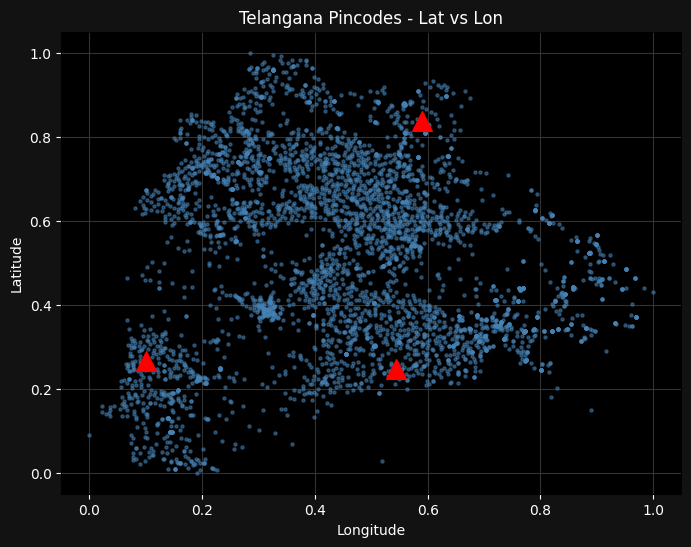

In [28]:
plt.figure(figsize=(8, 6))
ax = plt.subplot()
ax.grid(True, color="#323232")
ax.set_facecolor("black")
ax.figure.set_facecolor("#121212")
ax.tick_params(axis='x', color='white', labelcolor='white')
ax.tick_params(axis='y', color='white', labelcolor='white')
plt.scatter(X[:, 0], X[:, 1], s=5, alpha=0.5, color="steelblue", zorder=90)
plt.xlabel("Longitude", color="white")
plt.ylabel("Latitude", color="white")
plt.title("Telangana Pincodes - Lat vs Lon", color="white")

for i in clusters:
  center = clusters[i]['center']
  ax.scatter(center[0], center[1], marker='^', s=200, c='red', zorder=1000)

plt.show()

## The red triangles are our randomly initialized centroids.

In [29]:
class KMeans:
  def __init__(self, X, k=k, iters=iters):
    self.X = X
    self.k = k
    self.iters = iters
    self.clusters = {}
    self.pred = []

    for idx in range(self.k):
      self.clusters[idx] = {
          'center': X[np.random.randint(0, len(X))],
          'points': []
      }

  def assign_clusters(self):
    for idx in self.clusters:
      self.clusters[idx]['points'] = []

    for x in self.X:
      distances = []
      for i in self.clusters:
        distances.append(distance(x, self.clusters[i]['center']))
      cluster_idx = np.argmin(distances)
      self.clusters[cluster_idx]['points'].append(x)

  def update_clusters(self):
    for idx in self.clusters:
      if len(self.clusters[idx]['points']) > 0:
        self.clusters[idx]['center'] = np.mean(self.clusters[idx]['points'], axis=0)

  def pred_cluster(self):
    self.pred = []
    for x in self.X:
      dist = []
      for j in self.clusters:
        dist.append(distance(x, self.clusters[j]['center']))
      self.pred.append(np.argmin(dist))

    return self.pred

  def fit(self):
    for i in range(self.iters):
      self.assign_clusters()
      self.update_clusters()
    self.pred_cluster()
    print(np.unique(self.pred, return_counts=True))

  def plot(self):
    plt.figure(figsize=(8, 6))
    ax = plt.subplot()
    ax.set_facecolor("black")
    ax.figure.set_facecolor("#121212")
    ax.grid(True, color="#323232")
    ax.tick_params(axis='x', color='white', labelcolor='white')
    ax.tick_params(axis='y', color='white', labelcolor='white')

    ax.scatter(self.X[:, 0], self.X[:, 1], c=self.pred, cmap='viridis', s=5, alpha=0.6)
    for i in self.clusters:
        center = self.clusters[i]['center']
        ax.scatter(center[0], center[1], marker='^', s=200, c='red', zorder=5)

    ax.set_title("K-Means Clustering — Telangana", color='white')
    ax.set_xlabel("Longitude (scaled)", color='white')
    ax.set_ylabel("Latitude (scaled)", color='white')
    plt.show()

(array([0, 1, 2]), array([1462,  911, 1824]))


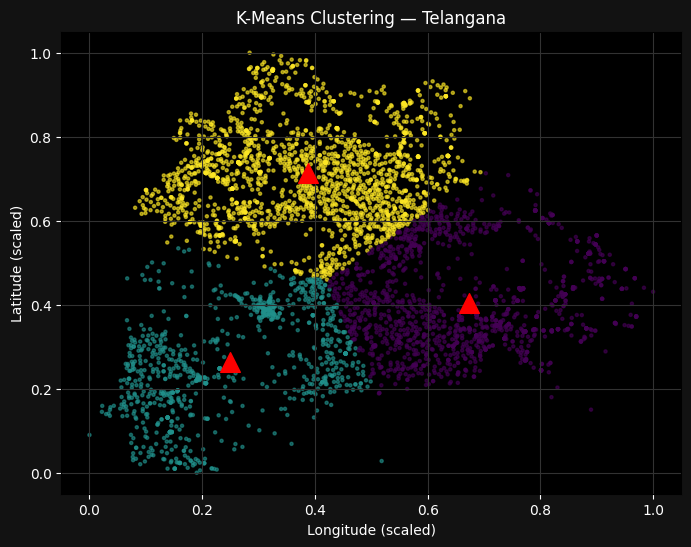

In [30]:
km = KMeans(X, k=3, iters=10)
km.fit()
km.plot()

## Clearly we see that the state of Telangana is split into 3 main regions. Let us try to overlay a map of Telangana onto it so that we can get more insights.

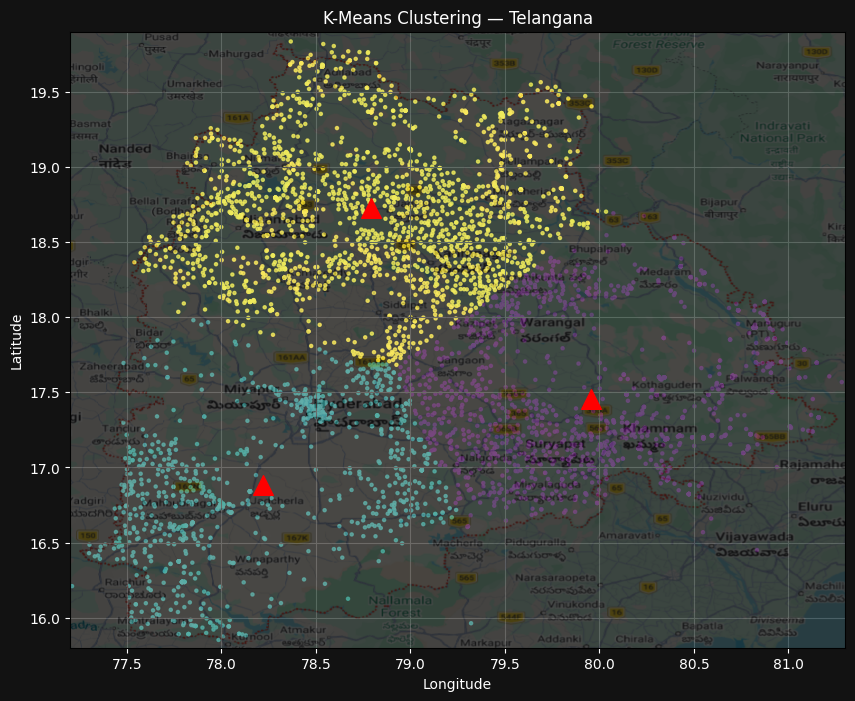

In [31]:
from PIL import Image

img = Image.open("telangana_map.png")

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("black")
ax.figure.set_facecolor("#121212")
ax.grid(True, color="#323232")
ax.tick_params(axis='x', color='white', labelcolor='white')
ax.tick_params(axis='y', color='white', labelcolor='white')

ax.imshow(img, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
          aspect='auto', alpha=0.3, zorder=2)

ax.scatter(data["Longitude"], data["Latitude"],
           c=km.pred, cmap='viridis', s=5, alpha=0.8, zorder=0)

for i in km.clusters:
    lon_c = km.clusters[i]['center'][0] * (LON_MAX - LON_MIN) + LON_MIN
    lat_c = km.clusters[i]['center'][1] * (LAT_MAX - LAT_MIN) + LAT_MIN
    ax.scatter(lon_c, lat_c, marker='^', s=200, c='red', zorder=5)

ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_title("K-Means Clustering — Telangana", color='white')
ax.set_xlabel("Longitude", color='white')
ax.set_ylabel("Latitude", color='white')
plt.show()

The clustering results validate the model's accuracy. Densely populated urban centers such as Hyderabad, Warangal, and Nizamabad show a higher concentration of data points, _**reflecting the greater number of postal codes in these areas.**_ Conversely, sparsely populated regions like the Bhadradri Kothagudem forest area show very few data points, which shows its rural nature. It is worth to note that each of these urban hotspots falls within a distinct cluster! This suggests that the model has identified meaningful geographical divisions across Telangana rather than grouping them randomly.

Below is an interactive visualization of the same data, which I found cool.
**Note: The below two cells are not written by me.**

Let's see the results for different values of k.

(array([0, 1]), array([2015, 2182]))
(array([0, 1, 2]), array([ 968, 1438, 1791]))
(array([0, 1, 2, 3]), array([1131,  908, 1151, 1007]))
(array([0, 1, 2, 3, 4]), array([ 864,  987,  506,  821, 1019]))
(array([0, 1, 2, 3, 4, 5]), array([714, 640, 696, 558, 809, 780]))
(array([0, 1, 2, 3, 4, 5, 6]), array([531, 477, 615, 522, 768, 853, 431]))


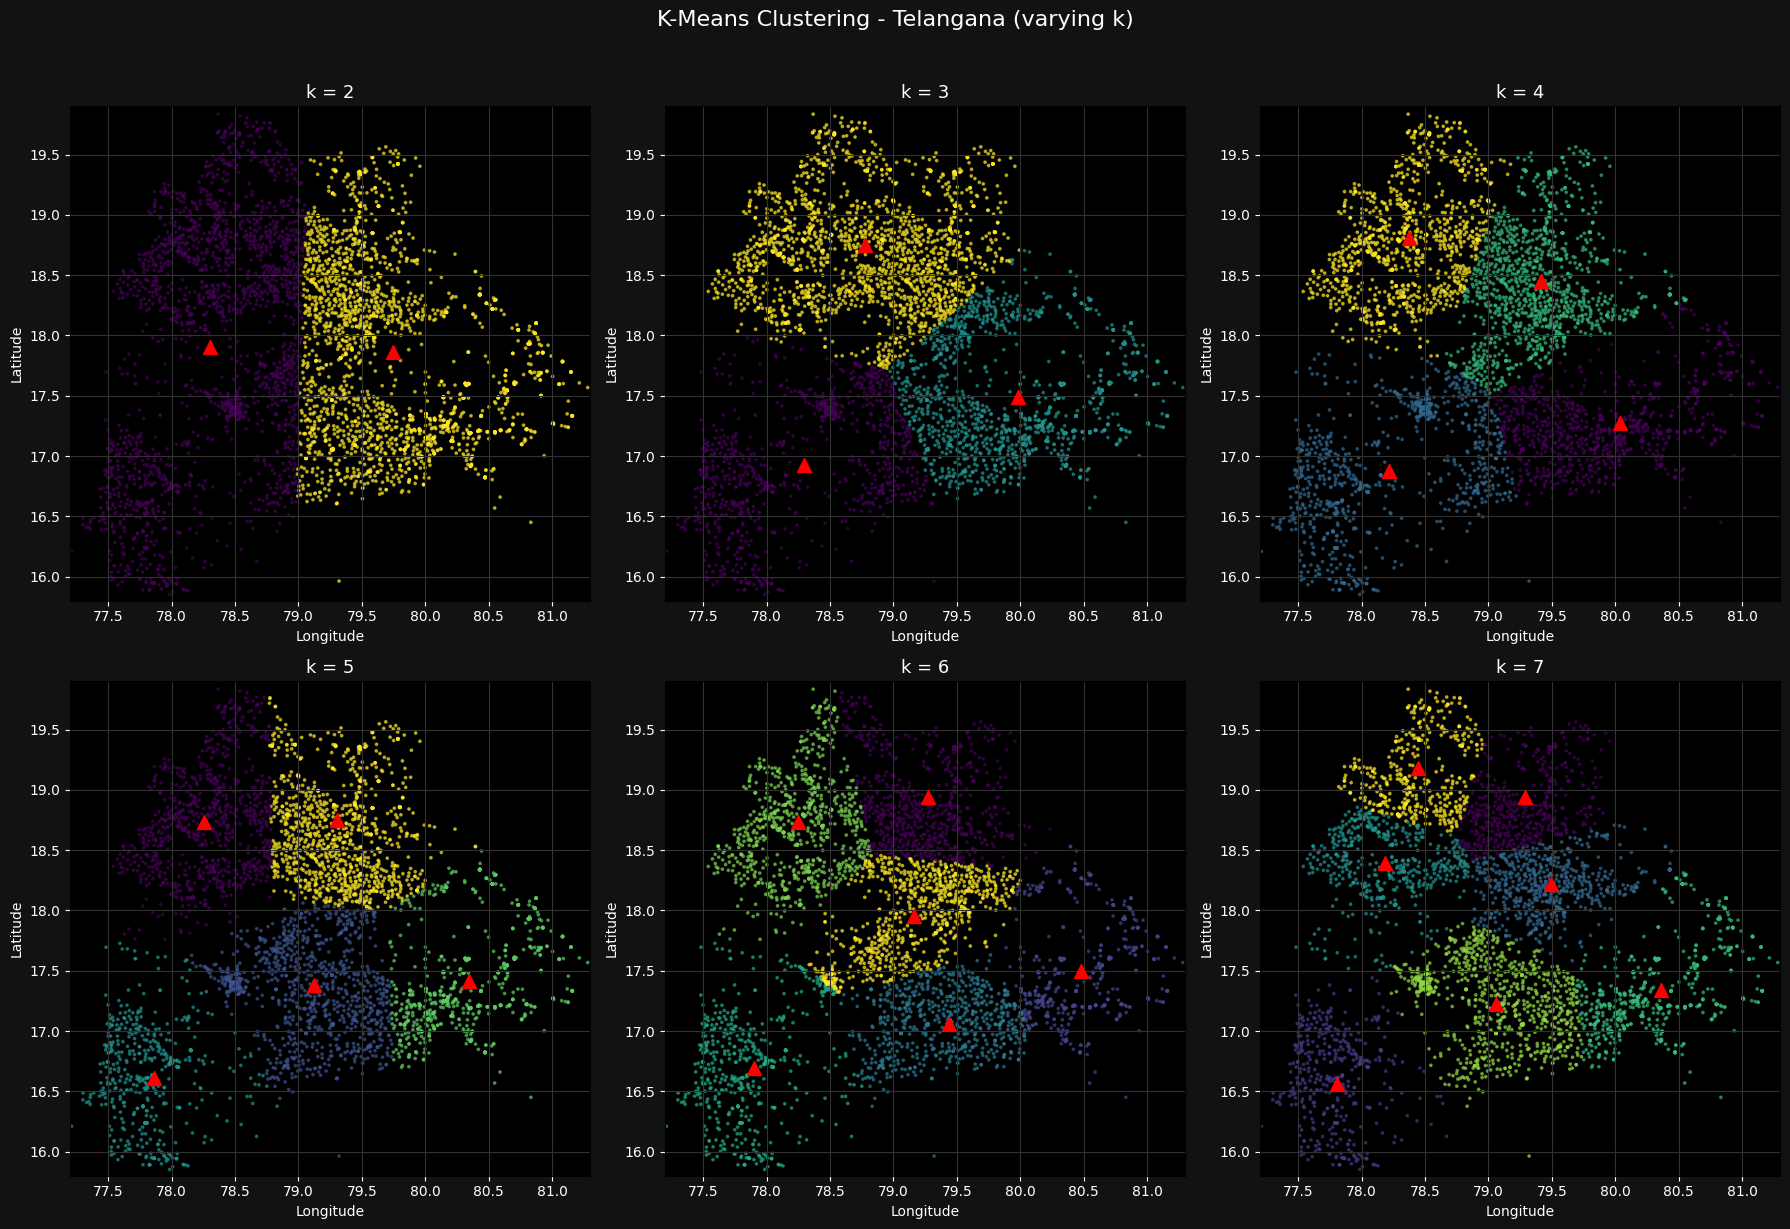

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor("#121212")
axes = axes.flatten()
ks = [2, 3, 4, 5, 6, 7]

for idx, k in enumerate(ks):
  km0 = KMeans(X, k=k, iters=10)
  km0.fit()
  pred = np.array(km0.pred)

  ax = axes[idx]
  ax.set_facecolor("black")
  ax.grid(True, color="#323232")
  ax.tick_params(axis='x', color='white', labelcolor='white')
  ax.tick_params(axis='y', color='white', labelcolor='white')

  ax.scatter(data["Longitude"], data["Latitude"],
             c=pred, cmap='viridis', s=3, alpha=0.6)

  for i in km0.clusters:
    lon_c = km0.clusters[i]['center'][0] * (LON_MAX - LON_MIN) + LON_MIN
    lat_c = km0.clusters[i]['center'][1] * (LAT_MAX - LAT_MIN) + LAT_MIN
    ax.scatter(lon_c, lat_c, marker='^', s=100, c='red', zorder=5)

  ax.set_xlim(77.2, 81.3)
  ax.set_ylim(15.8, 19.9)
  ax.set_title(f"k = {k}", color='white', fontsize=13)
  ax.set_xlabel("Longitude", color='white')
  ax.set_ylabel("Latitude", color='white')

plt.suptitle("K-Means Clustering - Telangana (varying k)",
             color='white', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
!pip install folium


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import folium
m = folium.Map(location=[17.5, 79.0], zoom_start=7)
colors = ['red', 'blue', 'green']
for i, (lon, lat) in enumerate(zip(data["Longitude"], data["Latitude"])):
    folium.CircleMarker([lat, lon], radius=2,
                        color=colors[km.pred[i]]).add_to(m)
m